# Boron in Pressurized Water Reactors 

##### Cecilie1, Ceilie2, Marie, Kristian

Simulate with: 
- Bor as burnable poison (added to moderator)
- Gad as burnable poison (added to fuel)

Determine: 
- $k_{eff}$
- concentration (loading vs. burnup)
- pin power distribution 
- poison worth

reactor design: 
- fuel: U235-0.04, U238-0.95, O16-2.0, dens-10.5
- cladding: Zr-1.0
- coolant: H1-2.0, O16-1.0
- 17x17 lattice 
- 25 controlrods?

In [1]:
import openmc
import openmc.model
import numpy as np
import matplotlib.pyplot as plt
import os

In the following the different functions are created to build the assembly

In [2]:
def material(name, density, temperature=293.6,  nuclides=None, elements=None): #function to create materials for the reactor 
    mat = openmc.Material(name=name, temperature=temperature) #material
    mat.set_density('g/cm3', density) #density of the material
    if nuclides: #if there are nuclides, add them to the material
        for nuclide, fraction in nuclides.items():
            mat.add_nuclide(nuclide, fraction)
    if elements: #if there are elements, add them to the material
        for element, fraction in elements.items():
            mat.add_element(element, fraction)
    return mat

def make_pin(fuel, coolant, clad, fuel_r=0.41, clad_r=0.45, gap_r=0.42, pitch=1.26): #creates pin cell. for a 17x17 assembly, the pitch is 1.26 cm
    fuel_or = openmc.ZCylinder(r=fuel_r) #fuel outer radius
    clad_or = openmc.ZCylinder(r=clad_r) #clad inner radius
    clad_ir = openmc.ZCylinder(r=gap_r) #clad inner radius
    
    left = openmc.XPlane(x0=-pitch/2) #left boundary
    right = openmc.XPlane(x0=pitch/2) #right boundary
    bottom = openmc.YPlane(y0=-pitch/2) #bottom boundary
    top = openmc.YPlane(y0=pitch/2) #top boundary
    
    fuel_region = -fuel_or                #inside the fuel cylinder
    gap_region = +fuel_or & -clad_ir      #outside of fuel cylinder and inside of clad inner cylinder
    clad_region = +clad_ir & -clad_or     #outside of clad inner cylinder and inside of clad outer cylinder
    mod_region = +clad_or & +left & -right & +bottom & -top #outside of clad outer cylinder and inside the boundaries
    
    fuel_cell = openmc.Cell(name='fuel', region=fuel_region, fill=fuel) #cell for fuel
    gap_cell = openmc.Cell(name='air gap', region=gap_region, fill=None) #cell for gap
    clad_cell = openmc.Cell(name='clad', region=clad_region, fill=clad) #cell for clad
    mod_cell = openmc.Cell(name='moderator', region=mod_region, fill=coolant) #cell for moderator
    
    pin = openmc.Universe(cells=[fuel_cell, gap_cell, clad_cell, mod_cell]) #create the pin universe
    return pin

def make_tube(clad, coolant, clad_r=0.45, inner_r=0.42, pitch=1.26): #creates the tube cell for the guide tube
    clad_or = openmc.ZCylinder(r=clad_r) #clad outer radius
    clad_ir = openmc.ZCylinder(r=inner_r) #clad inner radius
    
    left = openmc.XPlane(x0=-pitch/2) #left boundary
    right = openmc.XPlane(x0=pitch/2) #right boundary
    bottom = openmc.YPlane(y0=-pitch/2) #bottom boundary
    top = openmc.YPlane(y0=pitch/2) #top boundary
    
    inner_region = -clad_ir      #inside of clad inner cylinder
    clad_region = +clad_ir & -clad_or     #outside of clad inner cylinder and inside of clad outer cylinder
    mod_region = +clad_or & +left & -right & +bottom & -top #outside of clad outer cylinder and inside the boundaries
    
    inner_cell = openmc.Cell(name='guide tube water', region=inner_region, fill=coolant) #cell for gap
    clad_cell = openmc.Cell(name='guide tube clad',region=clad_region, fill=clad) #cell for clad
    mod_cell = openmc.Cell(name='guide tube moderator', region=mod_region, fill=coolant) #cell for moderator
    
    tube = openmc.Universe(cells=[inner_cell, clad_cell, mod_cell]) #create the tube universe
    return tube

def make_assembly(fuel_pin, guide_tube, gad = None, pitch=1.26, size=17): #creates the assembly by repeating the pin universe
    width = pitch * size #width of the assembly
    #assembly = openmc.RectLattice(name='assembly', pitch=(pitch, pitch), lower_left=(-width/2, -width/2)) 
    assembly = openmc.RectLattice(name='assembly') #create the lattice
    assembly.pitch = (pitch, pitch) #set the pitch of the lattice
    assembly.lower_left = (-width/2, -width/2) #set the lower left corner of the lattice
    universes = [[fuel_pin for j in range(size)] for i in range(size)] #create an array of the fuel pins
    guide_positions = [
    (2,5), (2,8), (2,11),
    (5,2), (5,5), (5,8), (5,11), (5,14),
    (8,2), (8,5), (8,8), (8,11), (8,14),
    (11,2), (11,5), (11,8), (11,11), (11,14),
    (14,5), (14,8), (14,11)
    ]
    for i, j in guide_positions:
        universes[i][j] = guide_tube
        
    assembly.universes = universes #set the universes of the lattice
    xmin = openmc.XPlane(x0=-width/2, boundary_type='reflective') #keeps neutrons from leaving the assembly
    xmax = openmc.XPlane(x0= width/2, boundary_type='reflective')
    ymin = openmc.YPlane(y0=-width/2, boundary_type='reflective')
    ymax = openmc.YPlane(y0= width/2, boundary_type='reflective')
    
    assembly_region = +xmin & -xmax & +ymin & -ymax #region of the assembly
    assembly_cell = openmc.Cell(name='assembly cell', region=assembly_region, fill=assembly) #cell for the assembly
    root = openmc.Universe(cells=[assembly_cell])
    geometry = openmc.Geometry(root)
    return geometry



Now we test if everything works


In [3]:
#creating the materials for the simulation.

fuel = material(
    'UO2',
    density=10.5,
    temperature=1200,
    nuclides={
        'U235': 0.04,
        'U238': 0.96,
        'O16': 2.0
    }
)

clad = material(
    'Zirconium',
    density=6.6,
    temperature=900,
    elements={
        'Zr': 1.0
    }
)

coolant = material(
    'Water',
    density=0.74,
    temperature=None,
    nuclides={
        'H1': 2.0,
        'O16': 1.0
    }
)

In [4]:
#creating the reactor geometry 
fuel_pin = make_pin(fuel, coolant, clad)
guide_tube = make_tube(clad, coolant)

geometry = make_assembly(fuel_pin, guide_tube, size=17)

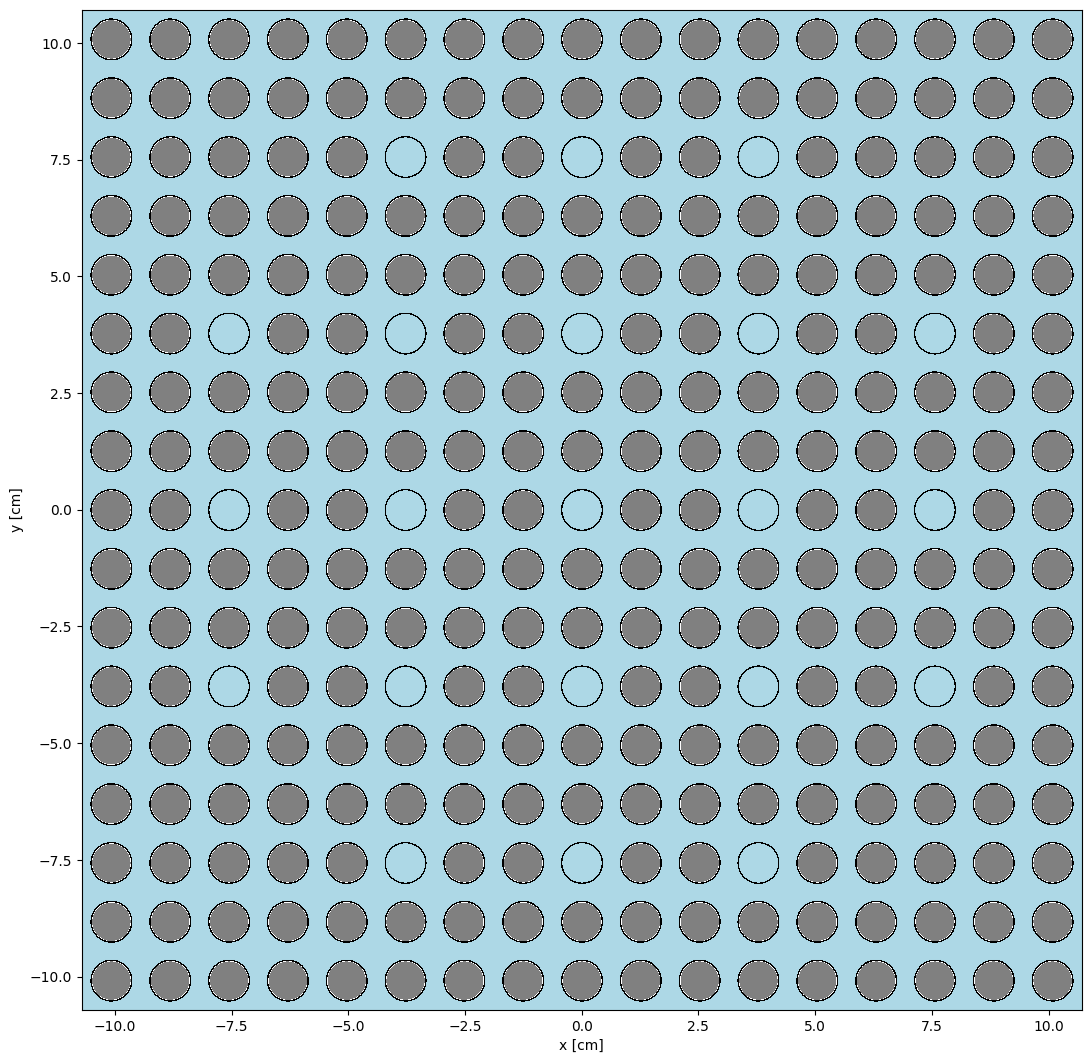

In [5]:
#Visual of reactor geometry. Colors are assigned to each material for better visualization.

colors = {
    fuel: 'grey',
    clad: 'black',
    coolant: 'lightblue'
}

geometry.plot(
    basis='xy',
    origin=(0, 0, 0),
    width=(17*1.26, 17*1.26),
    pixels=(1000, 1000),
    color_by='material',
    colors=colors
)

plt.show()

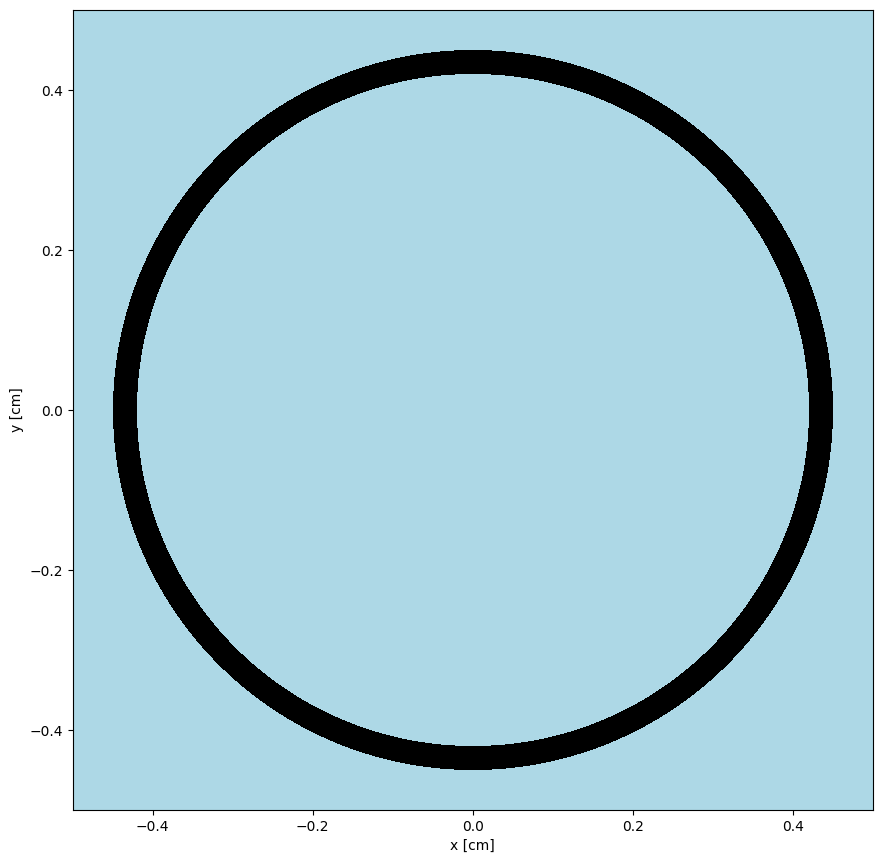

In [6]:
#visual of reactor geometry zoomed in to show the tube
geometry.plot(
    basis='xy',
    origin=(0, 0, 0),
    width=(1.0, 1.0),
    pixels=(800, 800),
    color_by='material',
    colors=colors
)

plt.show()

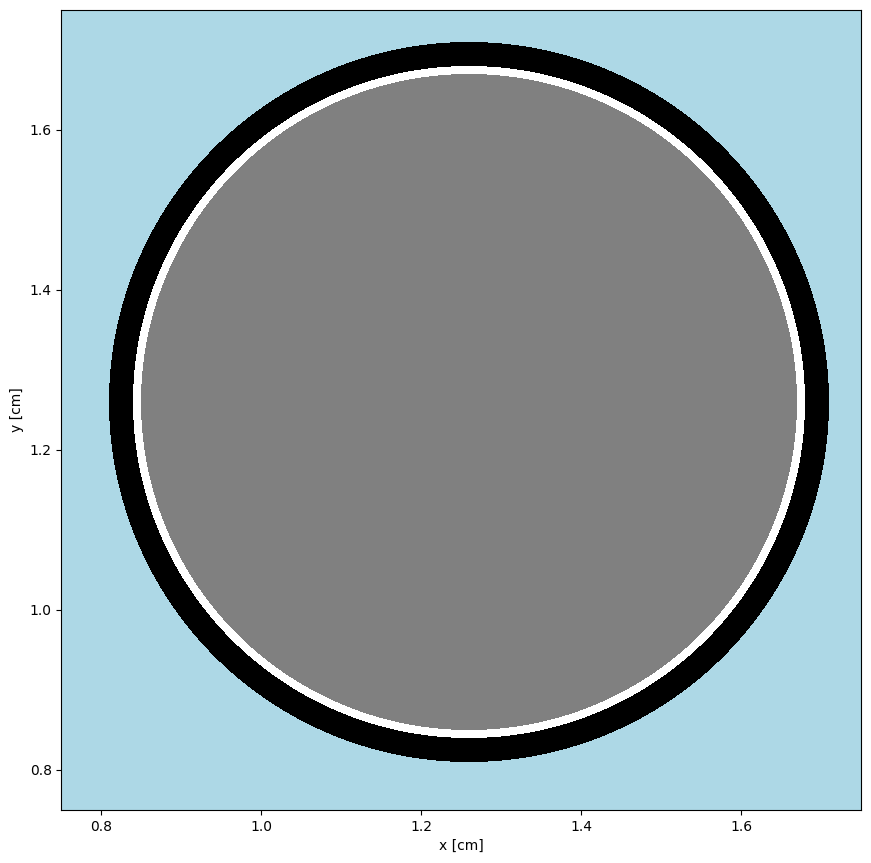

In [7]:
#visual of reactor geometry zoomed in to show the pin cell
geometry.plot(
    basis='xy',
    origin=(1.25, 1.25, 1),
    width=(1.0, 1.0),
    pixels=(800, 800),
    color_by='material',
    colors=colors
)

plt.show()

In [8]:
#simulation setting
width = 17 * 1.26

settings = openmc.Settings()
settings.run_mode = 'eigenvalue'
settings.batches = 150
settings.inactive = 30
settings.particles = 20000

source = openmc.IndependentSource(
    space=openmc.stats.Box(
        (-width/2, -width/2, -1),
        ( width/2,  width/2,  1),
        only_fissionable=True
    )
)
settings.source = source

/openmc_venv/lib/python3.12/site-packages/openmc/stats/multivariate.py:960: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "


In [9]:
#creating the model of the reactor

materials = openmc.Materials([fuel, clad, coolant])
model = openmc.Model(
    geometry=geometry,
    materials=materials,
    settings=settings
)

In [10]:
#check if model works
statepoint_file = model.run()




                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [ ]:
#finding the keff of the reactor
sp = openmc.StatePoint(statepoint_file)
print(sp.keff)

1.4102+/-0.0006


#### Finding $k_{eff}$

In the following the optimal pitch for the assembly is determined by maximizing $k_{eff}$. 

Parameters used to perform a seep of an array of different pitch values:
- No of Particles: 
- No of Batches: 150
- Inactive: 30
- pitches range [1,2]

In [11]:
#reflective boundary prevent neutrons from leaving assembly,therefore k_inf=max(k_eff). Find max(½k_eff) by varying the pitch of the assembly.
import tempfile

def find_keff(pitches,geometry,materials,settings):
    keffs = []
    unc =  []
    for pitch in pitches:
        fuel_pin = make_pin(fuel, coolant, clad, pitch=pitch)
        guide_tube = make_tube(clad, coolant, pitch=pitch)
        geometry = make_assembly(fuel_pin, guide_tube, pitch=pitch, size=17)
        settings_sweep = settings #copy the settings to modify for each run
        settings_sweep.particles = 5000
        settings_sweep.batches = 150
        settings_sweep.inactive = 30
        model = openmc.Model(
            geometry=geometry,
            materials=materials,
            settings=settings_sweep
        )
        with tempfile.TemporaryDirectory(prefix='openmc_exp2_') as run_dir:
            output = model.run(cwd=run_dir)
            with openmc.StatePoint(output) as sp_local:
                k_val = sp_local.keff.nominal_value
                unc_val = sp_local.keff.std_dev
            keffs.append(k_val)
            unc.append(unc_val)
    return keffs, unc
    
    



In [12]:
pitches =  np.arange(1.0,2 ,0.02)
keffs, uncertainties = find_keff(pitches, geometry, materials, settings)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

Optimal pitch: 1.62 cm
Maximum k_eff: 1.46751


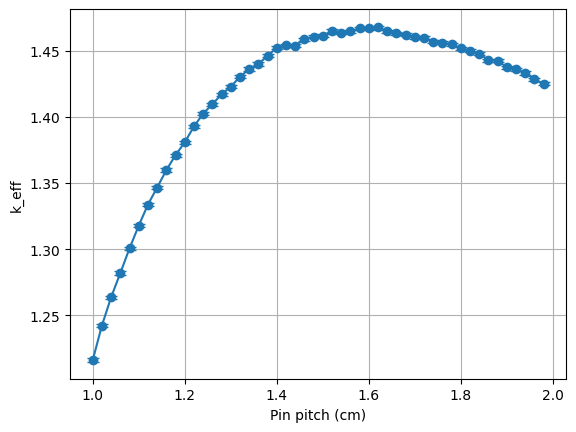

In [13]:
best_index = np.argmax(keffs)

best_pitch = pitches[best_index]
best_keff = keffs[best_index]

print(f'Optimal pitch: {best_pitch:.2f} cm')
print(f'Maximum k_eff: {best_keff:.5f}')

plt.errorbar(
    pitches,
    keffs,
    yerr=uncertainties,
    marker='o',
    capsize=4
)

plt.xlabel('Pin pitch (cm)')
plt.ylabel('k_eff')
plt.grid(True)
plt.show()

#### Boron Concentration 

The model is created using the pitch determined above. In the following the critical boron content is found. 

In [ ]:
#Adding boron to coolant 
def make_coolant(bppm):
    coolant = material(
        'water',
        density=0.74,
        temperature=None,
        nuclides={
            'H1': 2.0,
            'O16': 1.0,
        })
    if bppm > 0:
        coolant.add_element('B', bppm * 1e-6)
    coolant.add_s_alpha_beta('c_H_in_H2O')
    return coolant

def model_with_boron(bppm):
    coolant = make_coolant(bppm)
    fuel_pin = make_pin(fuel, coolant, clad, pitch=best_pitch)
    guide_tube = make_tube(clad, coolant, pitch=best_pitch)
    geometry = make_assembly(fuel_pin, guide_tube, pitch=best_pitch)
    settings_sweep = openmc.Settings()
    settings_sweep.run_mode = 'eigenvalue'
    settings_sweep.particles = 5000
    settings_sweep.batches = 150
    settings_sweep.inactive = 30
    model = openmc.Model(
        geometry=geometry,
        materials=openmc.Materials([fuel, clad, coolant]),
        settings=settings_sweep
    )
    return model



In [ ]:
ppms = [0,1000,2000,3500,4000] #searching for the interval of boron ppm that brings k_eff below 1.0

for ppm in ppms:
    model = model_with_boron(ppm)
    with tempfile.TemporaryDirectory(prefix='openmc_exp2_') as run_dir:
        output = model.run(cwd=run_dir)
        with openmc.StatePoint(output) as sp_local:
            k_val = sp_local.keff.nominal_value
        print(f'Boron ppm: {ppm}, k_eff: {k_val:.5f}')

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [27]:
bracket = [1000.,3500.]
os.system('rm *h5')
crit_ppm, guesses, keffs = openmc.search_for_keff(model_with_boron, target=1.2, bracket=bracket,
                                                  tol=1e-2, print_iterations=True)

print('Critical Boron Concentration: {:4.0f} ppm'.format(crit_ppm))

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

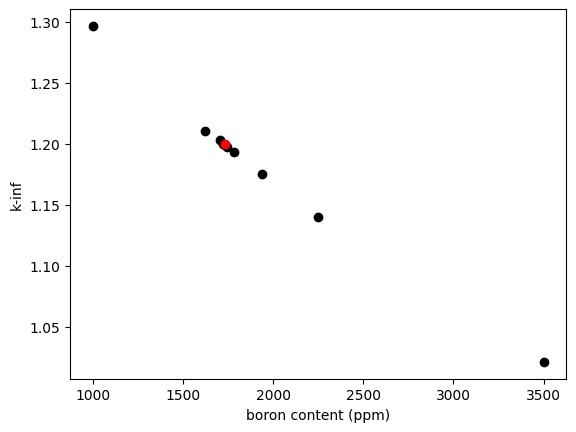

In [28]:
plt.figure()
for g,k in zip(guesses,keffs):
    plt.scatter(g,k.nominal_value,color='k')
plt.xlabel('boron content (ppm)')
plt.ylabel('k-inf')
plt.scatter(crit_ppm,1.2,color='r')
plt.show()